# **AI 500 - PA4** 

## Overview
This assignment covers Causal Inference and Exploratory Data Analysis (EDA). Complete all questions and follow the submission rules below.


## Instructions
- Attempt **all questions**.  
- Run **every notebook cell** sequentially. For the coding questions, each cell must display its result (print values, show tables or visualizations).  
- For the analytical questions, write your answers in the markdown cell provided to you below each question.
- All necessary imports are already provided — do not make any more imports.
- Fill the top markdown cell with your **Full Name** and **Roll Number**.  
- Save your notebook exactly as `PA4_<your_roll_number>.ipynb` (example: `PA4_26100053.ipynb`).  
- Due date: **22 November 2025** (submit by 23:55).  
- Plagiarism is <span style="color:red">strictly prohibited — submit your own original work.</span>

Write your name and roll number here:
- `Name:   Muhammad Ahmad `
- `Roll number:25280065` 

**Credit:** Based on the assignment developed during Dr. Ihsan Ayub Qazi's CS 334, Fall 2024 offering.


---

## **Part A - Analyzing the Impact of Castle Doctrine Laws on Violent Crime Rates**

### Introduction

The **Castle Doctrine** is a legal principle that grants individuals the right to use reasonable force, including deadly force, to defend themselves against an intruder within their own homes. Rooted in the notion that one's home is their "castle," these laws eliminate the duty to retreat before using force in self-defense. Proponents argue that the Castle Doctrine empowers lawful homeowners to protect themselves and deters criminal activity, while critics express concerns that such laws may escalate violence and lead to an increase in homicides.

Understanding the **causal relationship** between the implementation of Castle Doctrine laws and changes in violent crime rates is crucial for policymakers, law enforcement agencies, and communities. By analyzing this relationship, we can assess whether these laws effectively reduce crime or inadvertently contribute to higher rates of violence.

### Dataset Overview

This analysis utilizes a comprehensive dataset from the **FBI**, encompassing various states over multiple years. The dataset captures a wide range of variables related to violent crimes, socioeconomic conditions, and demographic factors. Notably, the implementation of Castle Doctrine laws occurred at different times across states, with the majority adopting these statutes around **2006**. This staggered adoption provides a unique opportunity to employ robust methodologies to isolate the effect of these laws on violent crime rates.

### Selected Columns for Analysis

For a focused and meaningful analysis, we restrict our examination to the following columns from the dataset:

| **Column**         | **Description**                                                                                                                                                                                                                 |
|--------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| `year`             | The calendar year of the observation (e.g., 2005, 2010).                                                                                                                                                                       |
| `post`             | A binary indicator where `1` signifies the post-treatment period (after the implementation of Castle Doctrine laws) and `0` denotes the pre-treatment period.                                                                    |
| `sid`              | The state identifier, uniquely representing each state in the dataset.                                                                                                                                                       |
| `homicide`         | The number of homicides recorded in the state per 100,000 population for the given year.                                                                                                                                       |
| `robbery`          | The number of robberies reported in the state per 100,000 population for the given year.                                                                                                                                        |
| `larceny`          | The number of larcenies recorded in the state per 100,000 population for the given year.                                                                                                                                        |
| `assault`          | The number of aggravated assaults reported in the state per 100,000 population for the given year.                                                                                                                              |
| `burglary`         | The number of burglaries recorded in the state per 100,000 population for the given year. 
| `l_exp_pubwelfare`         | Logged public welfare spending                                                                                                                                        |
| `l_police`         | Logged police presence                                                                                                                                        |
| `l_income`         | Logged income                                                                                                                                        |
| `murder`           | The number of murders reported in the state per 100,000 population for the given year.                                                                                                                                          |
| `unemployrt`       | The unemployment rate in the state for the given year, serving as an economic indicator.                                                                                                                                          |
| `poverty`          | The poverty rate in the state for the given year, reflecting socioeconomic conditions.                                                                                                                                           |
| `blackm_15_24`     | The percentage of Black males aged 15-24 in the state for the given year.                                                                                                                                                        |
| `whitem_15_24`     | The percentage of White males aged 15-24 in the state for the given year.                                                                                                                                                        |
| `popwt`     | Population weight                                                                                                                                                                                                                       |

### **Crime Definitions**

To ensure clarity in our analysis, it's essential to define each of the key crime-related variables included in our dataset:

| **Variable**   | **Definition**                                                                                                                                                                                                                     |
|----------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **Homicide**   | **Homicide** is defined as the sum of **murder** and **non-negligent manslaughter**. It represents the total number of intentional killings within a state, normalized per 100,000 state population.                                 |
| **Murder**     | **Murder** refers to the unlawful killing of another human being without justification or valid excuse, committed with the necessary intention as defined by the law in a specific jurisdiction.                                           |
| **Larceny**    | **Larceny** is the unlawful taking and carrying away of personal property with the intent to deprive the rightful owner of it permanently. It encompasses various forms of theft that do not involve force or intimidation.               |
| **Assault**    | **Assault** involves the act of causing physical harm or unwanted physical contact to another person. This includes aggravated assaults, which are more severe and may involve the use of weapons or intent to cause serious injury.       |
| **Burglary**   | **Burglary** is the act of illegally entering a building or other areas without permission, typically with the intention of committing a further criminal offense inside. It does not necessarily involve theft or violence.            |
| **Robbery**    | **Robbery** is the act of taking property or money from a person through force, intimidation, or threat of violence. Unlike larceny, robbery involves direct confrontation and coercion against the victim.                                |


### **Temporal and Spatial Dimensions**

The dataset spans multiple states across the United States and covers several years, allowing for a longitudinal analysis of crime trends in relation to the implementation of Castle Doctrine laws. Most states adopted these statutes around **2006**, but the exact year of implementation varies, providing a natural experiment setting to evaluate the laws' impact. By comparing states before and after the adoption period and against states that did not adopt the law during the study period, we can effectively employ different techniques to infer causality.

---



In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import dowhy
from sklearn.linear_model import LinearRegression

Q1) Load `castle_doctrine_1.csv` into `df_1` and `castle_doctrine_2.csv` into `df_2`. Display the first 5 rows of `df_1` and last 5 rows of `df_2`.

In [12]:
df_1 = pd.read_csv("castle_doctrine_1.csv")
df_2 = pd.read_csv("castle_doctrine_2.csv")
print("First 5 rows of df_1:")
print(df_1.head())
print("\nLast 5 rows of df_2:")
print(df_2.tail())

First 5 rows of df_1:
    id    year   sid  post  l_exp_pubwelfare  l_police   l_income  unemployrt  \
0  575     NaN   6.0   0.0          6.774674  5.495338  10.821630    4.138185   
1  277  2002.0  27.0   0.0          6.807210  5.723646  10.650625    4.500000   
2  104  2005.0  11.0   0.0          7.077266  5.788776  10.845290    5.100000   
3  177  2001.0  18.0   0.0          7.218498  5.530656  10.765047    5.200000   
4  456  2005.0  43.0   0.0          7.487087  6.031345  10.692172    5.500000   

     poverty  blackm_15_24  whitem_15_24       popwt  
0  11.203561           NaN           NaN         NaN  
1  14.261345      0.754476     12.723339   921333.75  
2  14.413202      0.048599      0.298499  8871351.00  
3  14.815132      3.269265      5.064819  4105912.00  
4  15.560262      3.887660     13.213633  5885931.50  

Last 5 rows of df_2:
      id  homicide    murder    robbery    assault   burglary    larceny
545  545  2.524252  2.524252  13.980474  207.37703  450.87027  238

Q2.1) Store the total number of null values in both datasets in `nullTotal`.

In [17]:
nullTotal = df_1.isnull().sum().sum() + df_2.isnull().sum().sum()
print(nullTotal)

157


Q2.2) Store the number of rows containing null values in both datasets in `rowsNull`.

In [18]:
rows_null_df1 = df_1.isnull().any(axis=1).sum()
rows_null_df2 = df_2.isnull().any(axis=1).sum()
rowsNull = rows_null_df1 + rows_null_df2
print(rowsNull)

30


Q3) Drop all rows containing null values, and print the sizes of the resulting datasets.

In [19]:
df_1 = df_1.dropna()
df_2 = df_2.dropna()
print("Size of df_1 after dropping null rows:", df_1.shape)
print("Size of df_2 after dropping null rows:", df_2.shape)

Size of df_1 after dropping null rows: (550, 12)
Size of df_2 after dropping null rows: (550, 7)


Q4) Note that the id column in `df_1` is shuffled and not in order. Sort all the rows in the dataframe in ascending order using the `id` column.

In [20]:
df_1 = df_1.sort_values(by="id", ascending=True)
df_1

,id,year,sid,post,l_exp_pubwelfare,l_police,l_income,unemployrt,poverty,blackm_15_24,whitem_15_24,popwt
139,0,2000.0,1.0,0.0,6.926083,5.854609,10.711102,4.1,14.705981,2.222243,4.694810,4499293.0
525,1,2001.0,1.0,0.0,6.974412,5.863135,10.675931,4.7,15.750203,2.249954,4.700201,4499293.0
22,2,2002.0,1.0,0.0,7.038751,5.741382,10.727071,5.4,15.556559,2.258261,4.685461,4499293.0
269,3,2003.0,1.0,0.0,7.110424,5.853816,10.695688,5.5,15.447802,2.292948,4.688166,4499293.0
455,4,2004.0,1.0,0.0,7.085519,5.792754,10.652069,5.1,16.252654,2.291327,4.661734,4499293.0
...,...,...,...,...,...,...,...,...,...,...,...,...
457,545,2006.0,51.0,0.0,7.099053,5.890402,10.837029,3.2,10.044194,0.128737,7.068100,504780.2
444,546,2007.0,51.0,0.0,7.129609,6.008737,10.844607,3.0,9.366708,0.138315,7.075853,504780.2
33,547,2008.0,51.0,0.0,7.147602,5.961206,10.896961,3.2,9.460956,0.136181,6.962835,504780.2
405,548,2009.0,51.0,0.0,7.220289,5.980045,10.884367,5.9,10.301384,0.147533,6.941324,504780.2


Q5.1) The dataset is split across two files; both files share an `id` column with identical row counts and therefore, a one-to-one mapping — join them on `id` and store the merged table in a variable named `df`.

In [21]:
df = pd.merge(df_1, df_2, on="id", how="inner")
df

,id,year,sid,post,l_exp_pubwelfare,l_police,l_income,unemployrt,poverty,blackm_15_24,whitem_15_24,popwt,homicide,murder,robbery,assault,burglary,larceny
0,0,2000.0,1.0,0.0,6.926083,5.854609,10.711102,4.1,14.705981,2.222243,4.694810,4499293.0,7.593978,6.532207,131.613570,325.61780,930.92017,2940.6238
1,1,2001.0,1.0,0.0,6.974412,5.863135,10.675931,4.7,15.750203,2.249954,4.700201,4499293.0,8.713443,7.494940,128.379600,281.63504,934.38460,2758.6900
2,2,2002.0,1.0,0.0,7.038751,5.741382,10.727071,5.4,15.556559,2.258261,4.685461,4499293.0,6.933288,6.406999,136.423310,274.63140,974.27570,2835.8290
3,3,2003.0,1.0,0.0,7.110424,5.853816,10.695688,5.5,15.447802,2.292948,4.688166,4499293.0,6.818007,6.567177,137.682700,258.53700,986.10266,2828.4238
4,4,2004.0,1.0,0.0,7.085519,5.792754,10.652069,5.1,16.252654,2.291327,4.661734,4499293.0,5.753689,5.595123,136.865310,255.65407,1011.78850,2800.9592
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
545,545,2006.0,51.0,0.0,7.099053,5.890402,10.837029,3.2,10.044194,0.128737,7.068100,504780.2,2.524252,2.524252,13.980474,207.37703,450.87027,2381.9233
546,546,2007.0,51.0,0.0,7.129609,6.008737,10.844607,3.0,9.366708,0.138315,7.075853,504780.2,4.085253,4.085253,16.341013,206.79164,459.49374,2314.3933
547,547,2008.0,51.0,0.0,7.147602,5.961206,10.896961,3.2,9.460956,0.136181,6.962835,504780.2,2.295188,2.295188,16.448847,197.00363,420.78445,2216.3865
548,548,2009.0,51.0,0.0,7.220289,5.980045,10.884367,5.9,10.301384,0.147533,6.941324,504780.2,2.099441,2.099441,14.886945,178.45248,415.30760,2158.6070


Q5.2) We do not need the `id` column any longer. Drop the `id` column.

In [ ]:
df = df.drop(columns=["id"])
df

,year,sid,post,l_exp_pubwelfare,l_police,l_income,unemployrt,poverty,blackm_15_24,whitem_15_24,popwt,homicide,murder,robbery,assault,burglary,larceny
0,2000.0,1.0,0.0,6.926083,5.854609,10.711102,4.1,14.705981,2.222243,4.694810,4499293.0,7.593978,6.532207,131.613570,325.61780,930.92017,2940.6238
1,2001.0,1.0,0.0,6.974412,5.863135,10.675931,4.7,15.750203,2.249954,4.700201,4499293.0,8.713443,7.494940,128.379600,281.63504,934.38460,2758.6900
2,2002.0,1.0,0.0,7.038751,5.741382,10.727071,5.4,15.556559,2.258261,4.685461,4499293.0,6.933288,6.406999,136.423310,274.63140,974.27570,2835.8290
3,2003.0,1.0,0.0,7.110424,5.853816,10.695688,5.5,15.447802,2.292948,4.688166,4499293.0,6.818007,6.567177,137.682700,258.53700,986.10266,2828.4238
4,2004.0,1.0,0.0,7.085519,5.792754,10.652069,5.1,16.252654,2.291327,4.661734,4499293.0,5.753689,5.595123,136.865310,255.65407,1011.78850,2800.9592
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
545,2006.0,51.0,0.0,7.099053,5.890402,10.837029,3.2,10.044194,0.128737,7.068100,504780.2,2.524252,2.524252,13.980474,207.37703,450.87027,2381.9233
546,2007.0,51.0,0.0,7.129609,6.008737,10.844607,3.0,9.366708,0.138315,7.075853,504780.2,4.085253,4.085253,16.341013,206.79164,459.49374,2314.3933
547,2008.0,51.0,0.0,7.147602,5.961206,10.896961,3.2,9.460956,0.136181,6.962835,504780.2,2.295188,2.295188,16.448847,197.00363,420.78445,2216.3865
548,2009.0,51.0,0.0,7.220289,5.980045,10.884367,5.9,10.301384,0.147533,6.941324,504780.2,2.099441,2.099441,14.886945,178.45248,415.30760,2158.6070


Q6.1) Plot a correlation heatmap for this dataset using the `selected_columns` (it should be a color coded graph indicating correlation values for each of the columns against every other column).

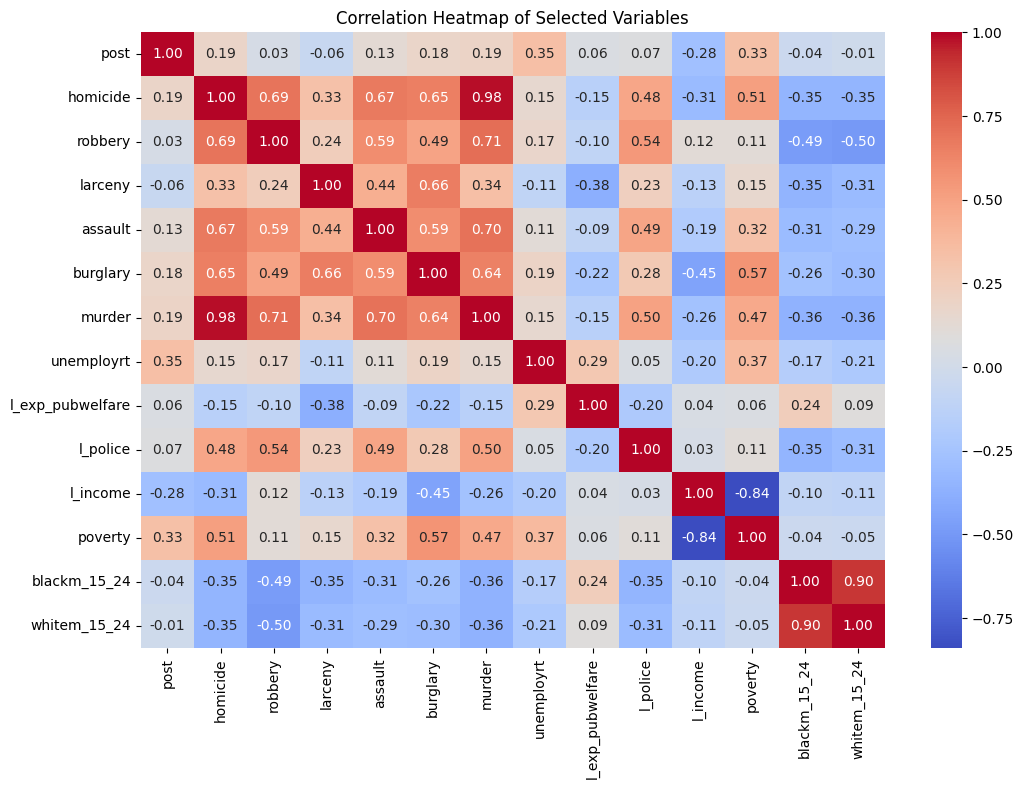

In [10]:
selected_columns = ['post', 'homicide', 'robbery', 'larceny', 
                    'assault', 'burglary', 'murder', 'unemployrt','l_exp_pubwelfare' ,'l_police','l_income',
                    'poverty', 'blackm_15_24', 'whitem_15_24']
corr_matrix = df[selected_columns].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Selected Variables")
plt.show()

Q6.2) Comment on any 3 notable correlations. Based on these correlations, can you say that any of the correlations you suggested are causally related? If so, is their causal relationship direct or indirect, and are there any cofounding variables you suspect? Otherwise, explain why you weren't able to deduce any causal relaion.

Note: You will be graded on how critically you have commented, not how much you write. So keep your answers crisp and to the point, but also think deeply. 

<span style="color:lightgreen"> Answer: </span>

Q7.1) Estimate the average treatment effect on Homicide before and after the doctrine was implemented using the post attribute in your dataset, without conditioning on any variable. Store your answer in the `ATE` variable.

In [53]:
ATE = df[df['post'] == 1]['homicide'].mean() - df[df['post'] == 0]['homicide'].mean()
ATE

Q7.2) What might the issue with the calculated ATE?

<span style="color:lightgreen"> Answer: </span>

Q8) Create a plot that shows the number of observations in the pre-treatment and post-treatment periods. Make sure your graph is properly labelled.

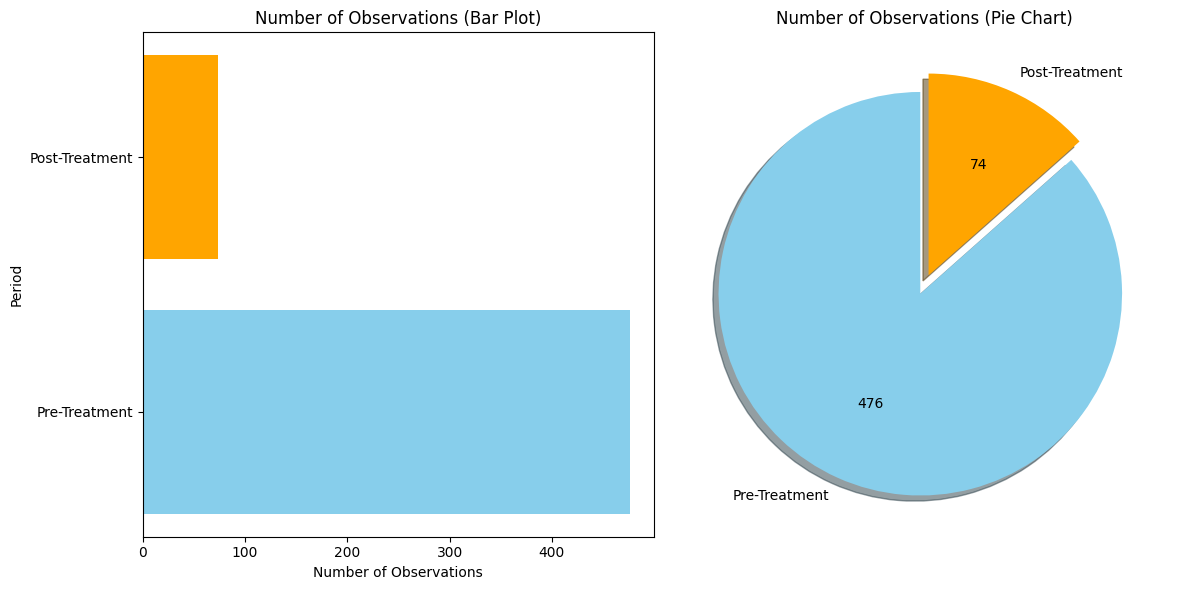

In [54]:

counts = df['post'].value_counts().sort_index()
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].barh(['Pre-Treatment', 'Post-Treatment'], counts, color=['skyblue', 'orange'])
axes[0].set_xlabel('Number of Observations')
axes[0].set_ylabel('Period')
axes[0].set_title('Number of Observations (Bar Plot)')
axes[1].pie(
    counts,
    labels=['Pre-Treatment', 'Post-Treatment'],
    autopct=lambda p: int(round(p * sum(counts) / 100)),
    colors=['skyblue', 'orange'],
    startangle=90,
    explode=[0.05, 0.05],
    shadow=True
)
axes[1].set_title('Number of Observations (Pie Chart)')
plt.tight_layout()
plt.show()


Q9.1) For the states that implemented the doctrine, use an appropriate plot to visualise the number of observations for the 5 states with the highest number of overall samples (pre and post). In the plot, separate counts for pre and post-treatment periods.

States that implemented the doctrine:
[ 1.  2.  3. 10. 11. 15. 17. 18. 19. 23. 25. 26. 27. 35. 36. 37. 41. 42.
 43. 44. 49.]
------------------------------------------------------

Filtered dataset (only implementing states):
     year  sid  post  l_exp_pubwelfare  l_police   l_income  unemployrt  \
0  2000.0  1.0   0.0          6.926083  5.854609  10.711102         4.1   
1  2001.0  1.0   0.0          6.974412  5.863135  10.675931         4.7   
2  2002.0  1.0   0.0          7.038751  5.741382  10.727071         5.4   
3  2003.0  1.0   0.0          7.110424  5.853816  10.695688         5.5   
4  2004.0  1.0   0.0          7.085519  5.792754  10.652069         5.1   

     poverty  blackm_15_24  whitem_15_24      popwt  homicide    murder  \
0  14.705981      2.222243      4.694810  4499293.0  7.593978  6.532207   
1  15.750203      2.249954      4.700201  4499293.0  8.713443  7.494940   
2  15.556559      2.258261      4.685461  4499293.0  6.933288  6.406999   
3  15.447802      2.292

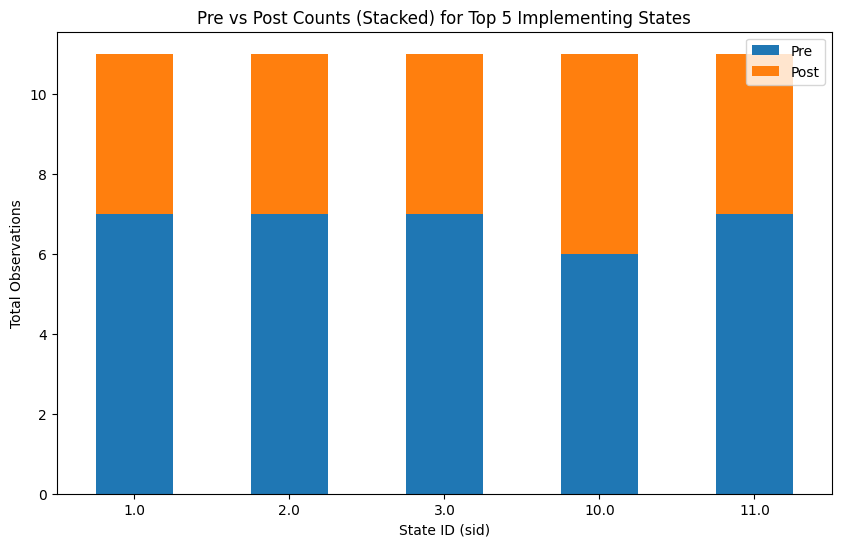

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [ ]:
implemented_states = df[df['post'] == 1]['sid'].unique()
print("States that implemented the doctrine:")
print(implemented_states)
print("------------------------------------------------------\n")
df_impl = df[df['sid'].isin(implemented_states)]
print("Filtered dataset (only implementing states):")
print(df_impl.head())
print("\nTotal rows in filtered dataset:", len(df_impl))
print("\n------------------------------------------------------\n")
print(" Pre vs Post counts for each implementing state:\n")
counts = df_impl.groupby(['sid', 'post']).size().unstack(fill_value=0)
counts.columns = ['Pre', 'Post']
print(counts)
print("\n------------------------------------------------------\n")
print(" Selecting top 5 states with highest total observations:\n")
top5 = counts.assign(total=counts['Pre'] + counts['Post']).nlargest(5, 'total')
print(top5)
print("\n------------------------------------------------------\n")
print(" Plotting results...\n")
top5[['Pre', 'Post']].plot(kind='bar', stacked=True, figsize=(10,6))
plt.xlabel("State ID (sid)")
plt.ylabel("Total Observations")
plt.title("Pre vs Post Counts (Stacked) for Top 5 Implementing States")
plt.xticks(rotation=0)
plt.legend()
plt.show()
plt.figure(figsize=(10,6))

Q9.2) Since our dataset comprises of data from many states, we want to calculate the per state ATE. Before we do that, we are interested in the ATE of the states with more data samples. Therefore, calculate the per state ATE of the 5 states you've visualised above and display the results in a dataframe.

In [66]:
ate_df = pd.DataFrame({
    'State_ID': top5.index,
    'ATE_Homicide': [
        df.loc[df['sid']==s, 'homicide'][df.loc[df['sid']==s, 'post']==1].mean() -
        df.loc[df['sid']==s, 'homicide'][df.loc[df['sid']==s, 'post']==0].mean()
        for s in top5.index
    ]
})
ate_df


,State_ID,ATE_Homicide
0,1.0,-0.222152
1,2.0,-0.962524
2,3.0,-0.531949
3,10.0,0.534881
4,11.0,-0.631924


Q9.3) Compute the overall CATE as follows:
- Select states that were treated in 2010.
- For each selected state, compute the state-level ATE on homicide:

Using the state-level ATEs, compute the CATE and report it.

In [68]:
treated_2010 = df[(df['post']==1) & (df['year']==2010)]['sid'].unique()
print("States treated in 2010:", treated_2010)
state_ates = []
for s in treated_2010:
    df_state = df[df['sid']==s]
    ate = df_state.loc[df_state['post']==1, 'homicide'].mean() - \
          df_state.loc[df_state['post']==0, 'homicide'].mean()
    state_ates.append(ate)
    print(f"State {s} ATE: {ate}")
CATE = np.mean(state_ates)
print("Overall CATE for states treated in 2010:", CATE)

States treated in 2010: [ 1.  2.  3. 10. 11. 15. 17. 18. 19. 23. 25. 26. 27. 35. 36. 37. 41. 42.
 43. 44. 49.]
State 1.0 ATE: -0.2221523321428558
State 2.0 ATE: -0.9625235892857145
State 3.0 ATE: -0.5319486071428576
State 10.0 ATE: 0.5348805233333334
State 11.0 ATE: -0.6319237607142858
State 15.0 ATE: -0.8765670000000005
State 17.0 ATE: -0.3712665821428569
State 18.0 ATE: -0.1418154499999993
State 19.0 ATE: 0.013524589285715649
State 23.0 ATE: -0.7133168357142852
State 25.0 ATE: -1.7126257857142866
State 26.0 ATE: 0.8060062000000014
State 27.0 ATE: -0.3013449600000002
State 35.0 ATE: 0.03407997416666664
State 36.0 ATE: -0.23012754444444372
State 37.0 ATE: 0.4499655392857136
State 41.0 ATE: -0.6236218321428568
State 42.0 ATE: 1.9132103142857142
State 43.0 ATE: -0.420971320833333
State 44.0 ATE: -0.7645958916666666
State 49.0 ATE: 0.3763001722222219
Overall CATE for states treated in 2010: -0.20842067520786078


Q9.4) Do you observe any evidence for the Simpson's Paradox for any individual state? If so, why do you think this might be the case?

<span style="color:lightgreen"> Answer: </span>

Q10) Now, report the ATE on Homicide using the DiD (Difference in Difference) formula where:

-   Assume the pre-intervention period is 2005, while the post-intervention period is 2010,
-   Given S defines your set of all states, your treatment group T consists of the states that have implemented the doctrine in 2010, and your control group are the states S\T in 2005 (i.e. the states apart from those incorporated in T)


In [70]:
treated_states = df[(df['post']==1) & (df['year']==2010)]['sid'].unique()
print("Treated states in 2010:", treated_states)
control_states = [s for s in df['sid'].unique() if s not in treated_states]
print("Control states:", control_states)
Y_T_post = df[(df['sid'].isin(treated_states)) & (df['year']==2010)]['homicide'].mean()
Y_T_pre = df[(df['sid'].isin(treated_states)) & (df['year']==2005)]['homicide'].mean()
Y_C_post = df[(df['sid'].isin(control_states)) & (df['year']==2010)]['homicide'].mean()
Y_C_pre = df[(df['sid'].isin(control_states)) & (df['year']==2005)]['homicide'].mean()

print("Treated group, post (2010) mean homicide:", Y_T_post)
print("Treated group, pre (2005) mean homicide:", Y_T_pre)
print("Control group, post (2010) mean homicide:", Y_C_post)
print("Control group, pre (2005) mean homicide:", Y_C_pre)


DiD_ATE = (Y_T_post - Y_T_pre) - (Y_C_post - Y_C_pre)
print("Difference-in-Differences (DiD) ATE on Homicide:", DiD_ATE)


Treated states in 2010: [ 1.  2.  3. 10. 11. 15. 17. 18. 19. 23. 25. 26. 27. 35. 36. 37. 41. 42.
 43. 44. 49.]
Control states: [np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64(16.0), np.float64(20.0), np.float64(21.0), np.float64(22.0), np.float64(24.0), np.float64(28.0), np.float64(29.0), np.float64(30.0), np.float64(31.0), np.float64(32.0), np.float64(33.0), np.float64(34.0), np.float64(38.0), np.float64(39.0), np.float64(40.0), np.float64(45.0), np.float64(46.0), np.float64(47.0), np.float64(48.0), np.float64(50.0), np.float64(51.0)]
Treated group, post (2010) mean homicide: 5.132316723809524
Treated group, pre (2005) mean homicide: 5.774291704761906
Control group, post (2010) mean homicide: 3.4650667172413794
Control group, pre (2005) mean homicide: 4.238357751724138
Difference-in-Differences (DiD) ATE on Homicide: 0.13131605353037656


Q11) Plot the overall average homicides per year in appropriate graph.

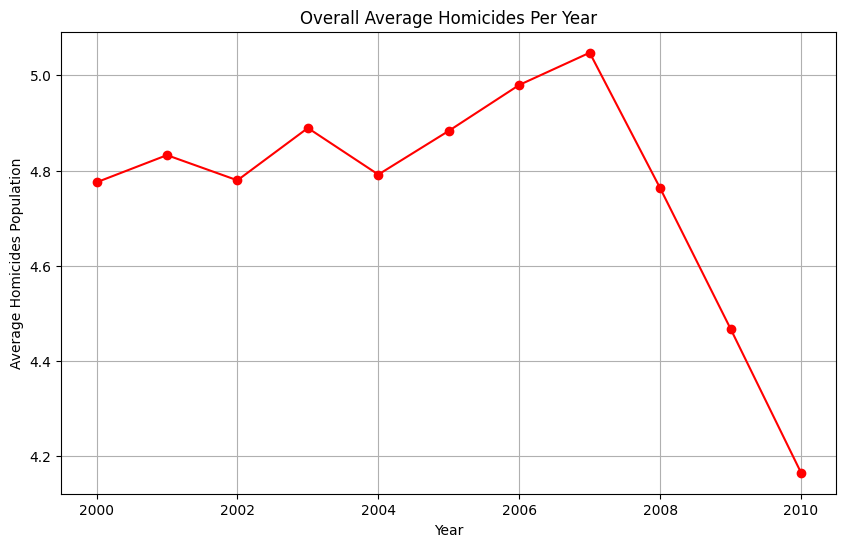

In [23]:
avg_homicide_per_year = df.groupby('year')['homicide'].mean()
plt.figure(figsize=(10,6))
plt.plot(avg_homicide_per_year.index, avg_homicide_per_year.values, marker='o', color='red')
plt.title('Overall Average Homicides Per Year')
plt.xlabel('Year')
plt.ylabel('Average Homicides Population')
plt.grid(True)
plt.show()



Q12) Synthesize the results from your analyses (correlation heatmap, raw ATE, per‑state ATEs, CATE, DiD, plots). Based on this evidence, state whether you believe the Castle Doctrine had a causal effect, positive or negative, on homicide rates and justify your conclusion with specific findings. Then list the main limitations and identification threats in your approach.

Cite specific results (numbers or trends) that support or contradict a causal effect.
Identify likely confounders and how they could bias estimates.
Note methodological limitations (e.g., aggregated vs. within‑state effects, parallel trends assumption for DiD).

(There is no correct answer for this question so please be thorough in your response).

<span style="color:lightgreen"> Answer: </span>

## **Part B - Analyzing the Impact of Digital Notes on GPA**

We tested whether taking notes digitally affects students' GPA. In an experiment with 1,000 students we recorded a binary indicator for digital note-taking, measured each student's change in GPA after one year, and logged weekly study hours (scaled). Use the file `digital_notes.csv` for the analysis. For this task, we will be using the `doWhy` library. Please refer to the documentation to solve this part: https://www.pywhy.org/dowhy/v0.13/getting_started/index.html.

Q13) Start by loading the data into a dataframe and displaying the first 5 rows of it.

In [24]:
df_notes = pd.read_csv("digital_notes.csv")
df_notes.head()

,study_hours,digital_notes,effect_on_gpa
0,-0.228014,False,-0.116390
1,1.448314,False,0.793924
2,1.919683,True,1.555616
3,1.801566,False,0.991375
4,1.684526,True,1.425603


Q14) Plot the number of students who used digital notes versus those who did not. Use a clearly labeled plot, include a title and axis labels, and display the plot.

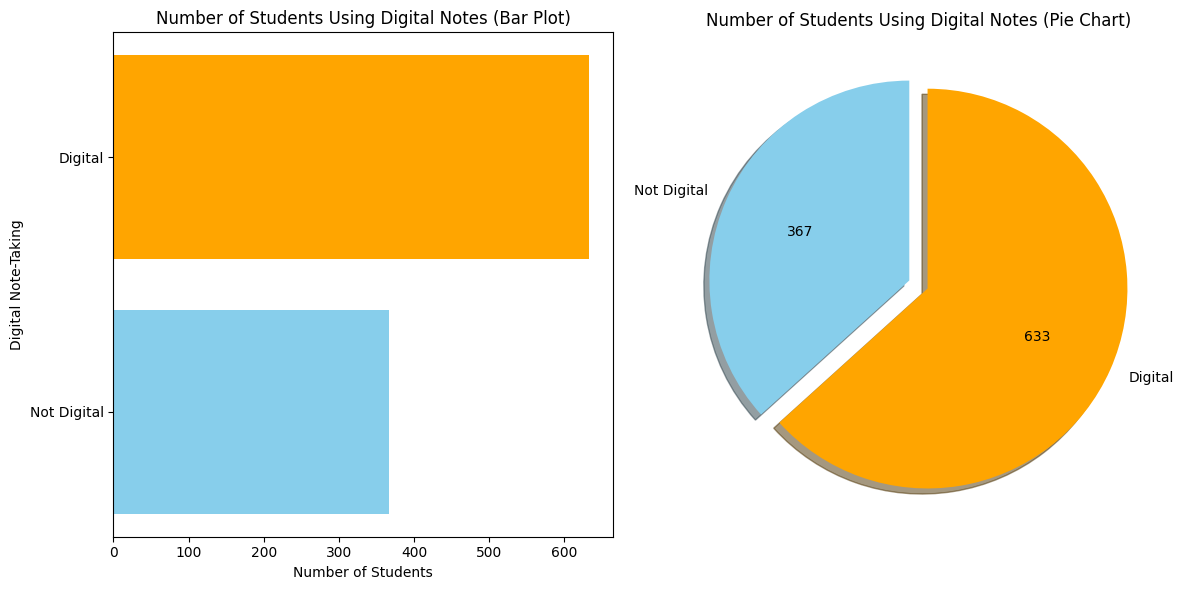

In [ ]:
counts = df_notes['digital_notes'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].barh(['Not Digital', 'Digital'], counts, color=['skyblue', 'orange'])
axes[0].set_xlabel('Number of Students')
axes[0].set_ylabel('Digital Note-Taking')
axes[0].set_title('Number of Students Using Digital Notes (Bar Plot)')
axes[1].pie(counts,
            labels=['Not Digital', 'Digital'],
            autopct=lambda p: int(round(p*sum(counts)/100)),  # show counts
            colors=['skyblue', 'orange'],
            startangle=90,
            explode=[0.05, 0.05],
            shadow=True)
axes[1].set_title('Number of Students Using Digital Notes (Pie Chart)')

plt.tight_layout()
plt.show()

Q15.1) Althought counterintuitive at first, we make an informed hypothesis that weekly study hours could affect both digital note usage and GPA (think about what this means). Use this information and the given data to generate a `CausalModel` using the `doWhy` library. Visualise the constructed model.

In [28]:
df_notes['digital_notes'] = df_notes['digital_notes'].astype(int)

In [29]:
model = dowhy.CausalModel(
    data=df_notes,
    treatment='digital_notes',
    outcome='effect_on_gpa',
    common_causes=['study_hours']
)
identified_estimand = model.identify_effect()
print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
       d                                     
───────────────(E[effect_on_gpa|study_hours])
d[digitalₙₒₜₑₛ]                              
Estimand assumption 1, Unconfoundedness: If U→{digital_notes} and U→effect_on_gpa then P(effect_on_gpa|digital_notes,study_hours,U) = P(effect_on_gpa|digital_notes,study_hours)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
       d                                     
───────────────(E[effect_on_gpa|study_hours])
d[digitalₙₒₜₑₛ]                              
Estimand assumption 1, Unconfoundedness: If U→{digital_notes} and U→effect_on_gpa then P(effect_on_gpa|digital_notes,study_hours,U) = P(effect_on_gpa|digital_notes,study_hours)



Q15.1) What is the confounding variable in our experiment?

<span style="color:lightgreen"> Answer: </span>

Q15.2) Use the constructed DAG to list all possible frontdoor and backdoor paths.

<span style="color:lightgreen"> Answer: </span>

Q16) Compute and report the ATE of digital note-taking on GPA using the dataframe.

In [32]:
causal_estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression"
)

# Report ATE
print("Average Treatment Effect (ATE) of digital note-taking on GPA:", causal_estimate.value)

Average Treatment Effect (ATE) of digital note-taking on GPA: 0.4998145259209862


In [36]:
ate_raw = df_notes[df_notes['digital_notes']==1]['effect_on_gpa'].mean() - \
          df_notes[df_notes['digital_notes']==0]['effect_on_gpa'].mean()
print("Raw mean difference (unadjusted ATE):", ate_raw)


Raw mean difference (unadjusted ATE): 0.7618892735085778


Q17) Use the `doWhy` library to identify the effects of each variable and then print the identified estimand. (this is just one line of code -> read the documentation carefully)

In [37]:
identified_estimand = model.identify_effect()
print(identified_estimand)


Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
       d                                     
───────────────(E[effect_on_gpa|study_hours])
d[digitalₙₒₜₑₛ]                              
Estimand assumption 1, Unconfoundedness: If U→{digital_notes} and U→effect_on_gpa then P(effect_on_gpa|digital_notes,study_hours,U) = P(effect_on_gpa|digital_notes,study_hours)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
       d                                     
───────────────(E[effect_on_gpa|study_hours])
d[digitalₙₒₜₑₛ]                              
Estimand assumption 1, Unconfoundedness: If U→{digital_notes} and U→effect_on_gpa then P(effect_on_gpa|digital_notes,study_hours,U) = P(effect_on_gpa|digital_notes,study_hours)



Q18) Using the identified estimate, use linear regression from `doWhy` to predict the causal estimate. 

In [38]:
causal_estimate = model.estimate_effect(identified_estimand, method_name="backdoor.linear_regression")
print("Causal Estimate of Digital Note-Taking on GPA:", causal_estimate.value)


Causal Estimate of Digital Note-Taking on GPA: 0.4998145259209862


Q19.1) We will now calculate the ATE using `LinearRegression` from the `sklearn` library. Do this without adjusting for the confounding variables first.

In [39]:
# Convert digital_notes to numeric 0/1
df_notes['digital_notes_num'] = df_notes['digital_notes'].astype(int)

# Define X (treatment) and y (outcome)
X = df_notes[['digital_notes_num']]
y = df_notes['effect_on_gpa']

# Fit linear regression
reg = LinearRegression().fit(X, y)

# The coefficient of digital_notes is the unadjusted ATE
ate_unadjusted = reg.coef_[0]
print("Unadjusted ATE (without adjusting for study_hours):", ate_unadjusted)

Unadjusted ATE (without adjusting for study_hours): 0.7618892735085749


Q19.2) Now, predict the ATE with adjustment for the confounding variable.

In [40]:
df_notes['digital_notes_num'] = df_notes['digital_notes'].astype(int)

# Define X (treatment + confounder) and y (outcome)
X = df_notes[['digital_notes_num', 'study_hours']]
y = df_notes['effect_on_gpa']

# Fit linear regression
reg = LinearRegression().fit(X, y)

# The coefficient of digital_notes is the adjusted ATE
ate_adjusted = reg.coef_[0]
print("Adjusted ATE (controlling for study_hours):", ate_adjusted)

Adjusted ATE (controlling for study_hours): 0.49981452592098463


Q20) Compare the unadjusted ATE and the ATE adjusted for study_hours. Report the numeric difference, explain why they differ, and state whether the evidence suggests digital note-taking improves GPA.

<span style="color:lightgreen"> Answer: </span>